In [2]:
import pandas as pd


In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\eren_\Downloads\archive (3)\Extended_Employee_Performance_and_Productivity_Data.csv")

print(df.shape)
df.head()


(100000, 20)


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [ ]:

if "Hire_Date" in df.columns:
    df["Hire_Date"] = pd.to_datetime(df["Hire_Date"], errors="coerce")


if "Education_Level" in df.columns:
    edu_order = ["High School","Bachelor","Master","PhD"]
    df["Education_Level"] = pd.Categorical(df["Education_Level"], categories=edu_order, ordered=True)


if "Remote_Work_Frequency" in df.columns:
    df["Remote_Work_Frequency"] = (
        df["Remote_Work_Frequency"]
        .astype(str).str.replace("%","", regex=False).str.strip()
    )
    df["Remote_Work_Frequency"] = pd.to_numeric(df["Remote_Work_Frequency"], errors="coerce")

attr_types = {}
for c in df.columns:
    if pd.api.types.is_datetime64_any_dtype(df[c]):
        typ = "datetime"
    elif pd.api.types.is_numeric_dtype(df[c]):
        typ = "numeric"
    elif pd.api.types.is_categorical_dtype(df[c]):
        typ = "categorical (ordered)" if getattr(df[c], "ordered", False) else "categorical"
    else:
        typ = "categorical"
    attr_types[c] = typ

attr_types_df = pd.DataFrame({"Attribute": list(attr_types.keys()), "Type": list(attr_types.values())})
print("Number of samples:", len(df))
print("Number of attributes:", df.shape[1])
attr_types_df


Number of samples: 100000
Number of attributes: 20


C:\Users\eren_\AppData\Local\Temp\ipykernel_31264\2843825913.py:26: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[c]):


,Attribute,Type
0,Employee_ID,numeric
1,Department,categorical
2,Gender,categorical
3,Age,numeric
4,Job_Title,categorical
5,Hire_Date,datetime
6,Years_At_Company,numeric
7,Education_Level,categorical
8,Performance_Score,numeric
9,Monthly_Salary,numeric


In [ ]:
missing_df = df.isna().sum().reset_index()
missing_df.columns = ["Attribute","Missing_Count"]
missing_df["Missing_%"] = (missing_df["Missing_Count"]/len(df)*100).round(2)
missing_df.sort_values("Missing_Count", ascending=False)


,Attribute,Missing_Count,Missing_%
0,Employee_ID,0,0.0
1,Department,0,0.0
2,Gender,0,0.0
3,Age,0,0.0
4,Job_Title,0,0.0
5,Hire_Date,0,0.0
6,Years_At_Company,0,0.0
7,Education_Level,0,0.0
8,Performance_Score,0,0.0
9,Monthly_Salary,0,0.0


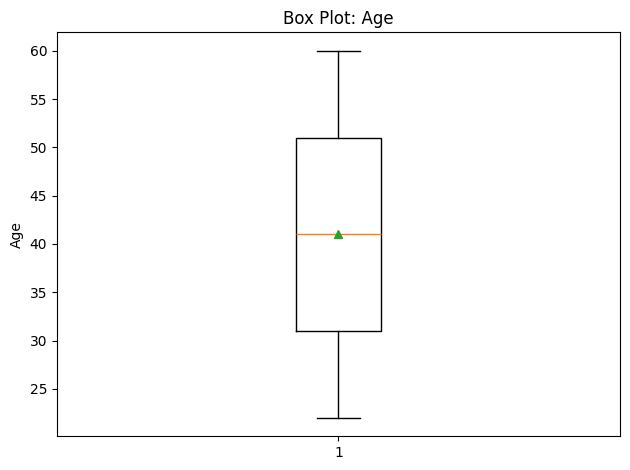

Saved -> hr_eda_figs\box_Age.png


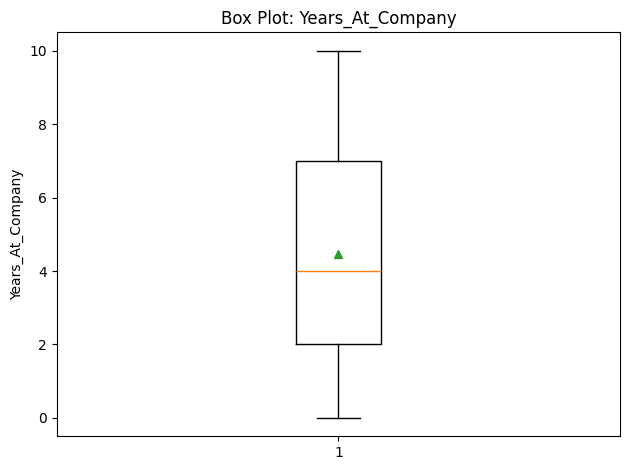

Saved -> hr_eda_figs\box_Years_At_Company.png


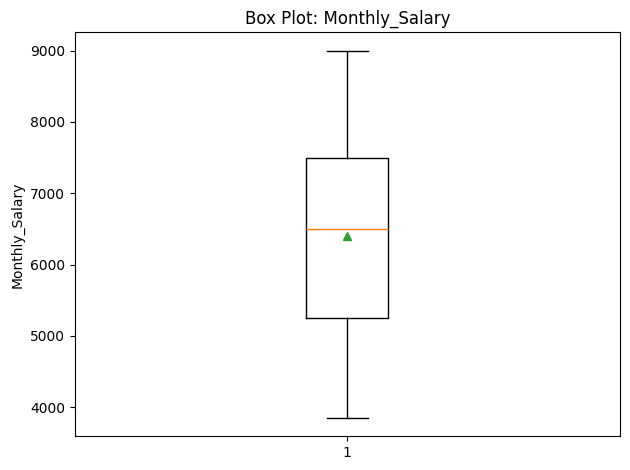

Saved -> hr_eda_figs\box_Monthly_Salary.png


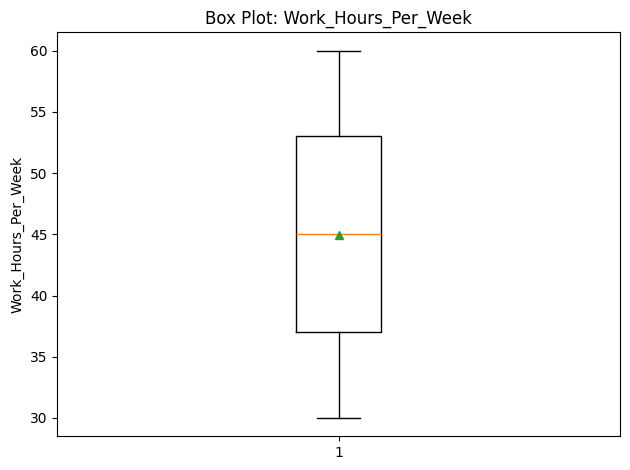

Saved -> hr_eda_figs\box_Work_Hours_Per_Week.png


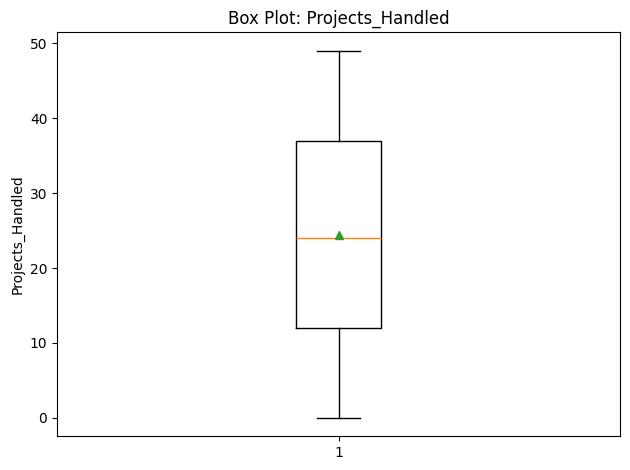

Saved -> hr_eda_figs\box_Projects_Handled.png


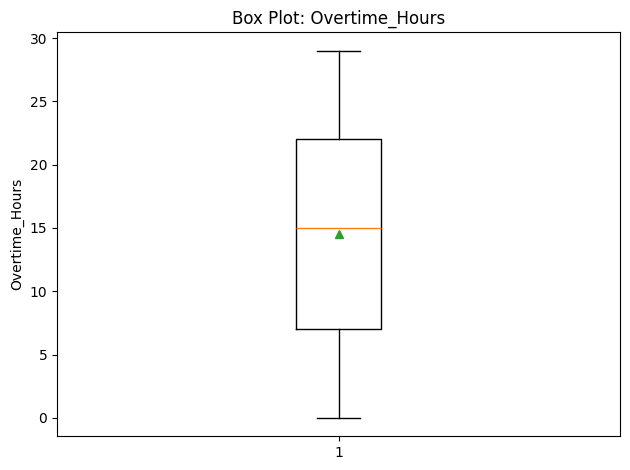

Saved -> hr_eda_figs\box_Overtime_Hours.png


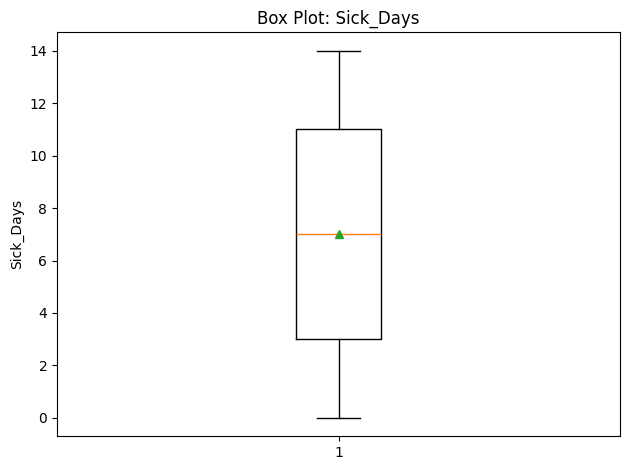

Saved -> hr_eda_figs\box_Sick_Days.png


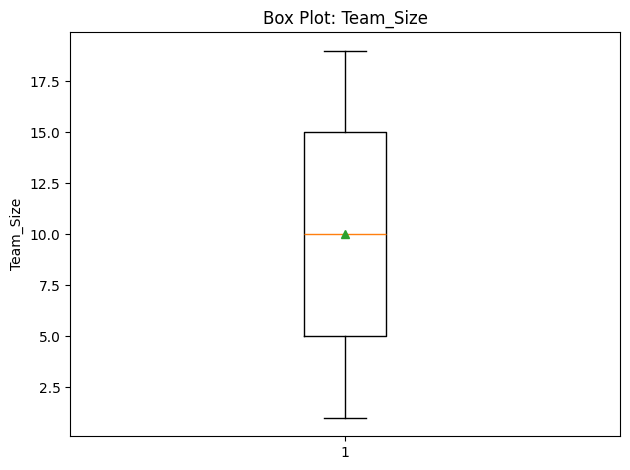

Saved -> hr_eda_figs\box_Team_Size.png


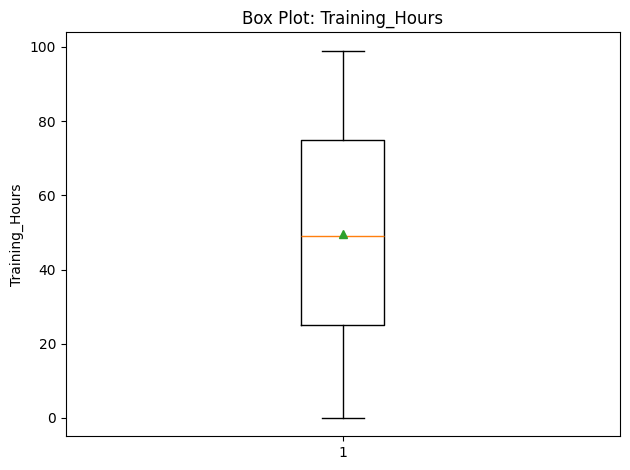

Saved -> hr_eda_figs\box_Training_Hours.png


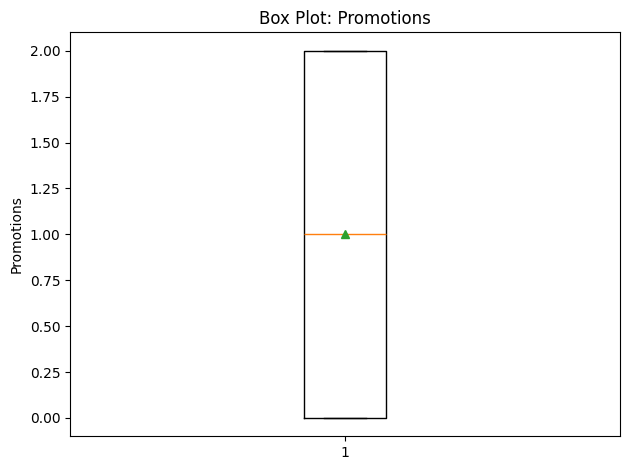

Saved -> hr_eda_figs\box_Promotions.png


In [ ]:
for c in numeric_cols:
    plt.figure()
    plt.boxplot(df[c].dropna(), vert=True, whis=1.5, showmeans=True)
    plt.title(f"Box Plot: {c}")
    plt.ylabel(c)
    savefig_show(f"box_{c}.png")


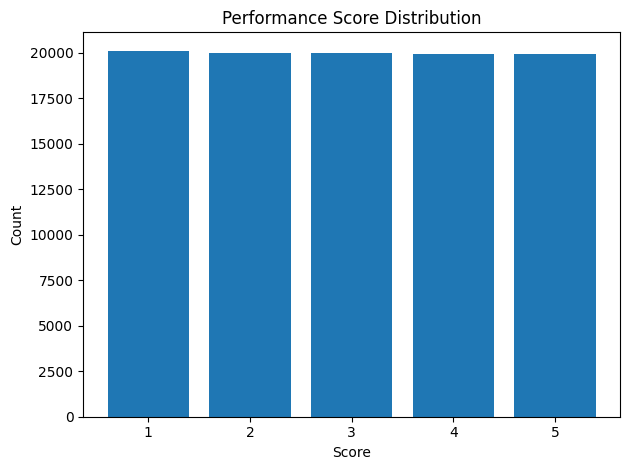

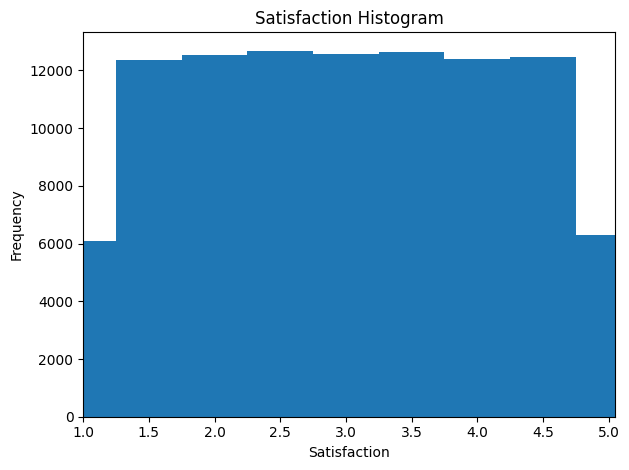

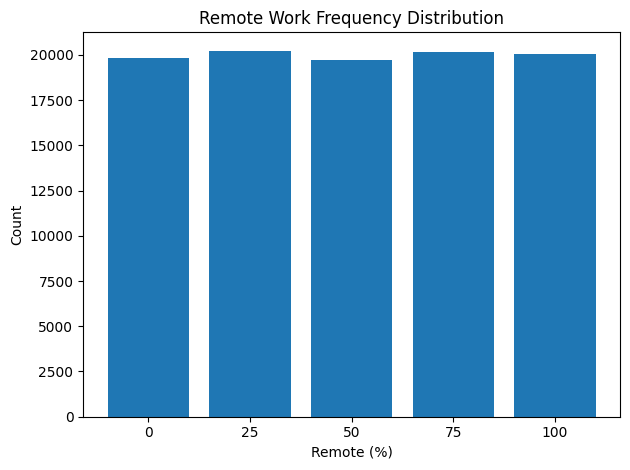

In [ ]:

vc = df["Performance_Score"].value_counts().sort_index()
plt.figure(); plt.bar([str(x) for x in vc.index], vc.values)
plt.title("Performance Score Distribution"); plt.xlabel("Score"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig("perf_bar.png", dpi=200); plt.show()


bins = np.arange(0.75, 5.26, 0.5)
plt.figure(); plt.hist(df["Employee_Satisfaction_Score"].dropna(), bins=bins)
plt.title("Satisfaction Histogram"); plt.xlabel("Satisfaction"); plt.ylabel("Frequency")
plt.xlim(1,5.05); plt.tight_layout(); plt.savefig("satisf_hist.png", dpi=200); plt.show()


vc = df["Remote_Work_Frequency"].value_counts().sort_index()
plt.figure(); plt.bar([str(x) for x in vc.index], vc.values)
plt.title("Remote Work Frequency Distribution"); plt.xlabel("Remote (%)"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig("remote_bar.png", dpi=200); plt.show()



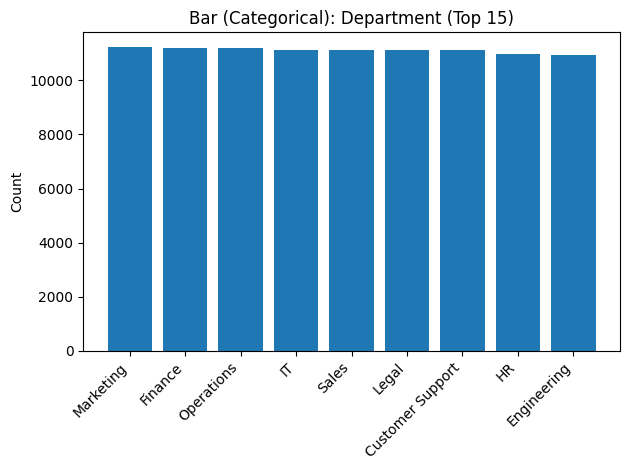

Saved -> hr_eda_figs\bar_Department.png


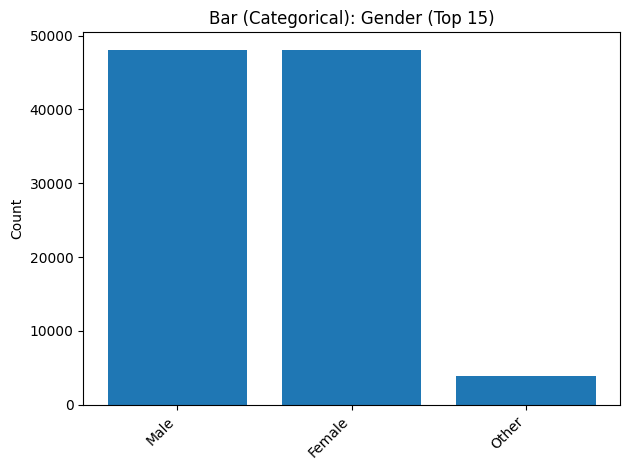

Saved -> hr_eda_figs\bar_Gender.png


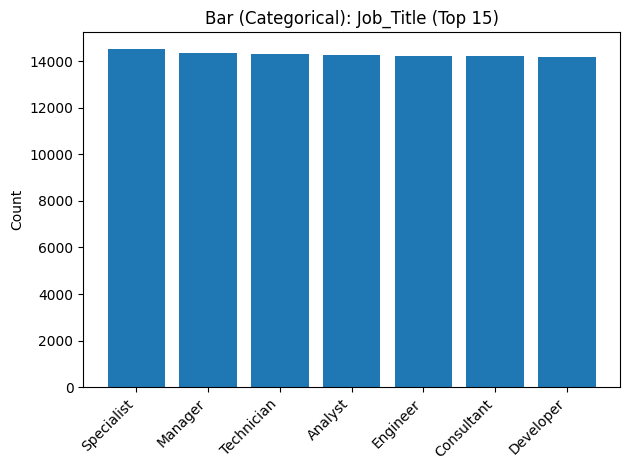

Saved -> hr_eda_figs\bar_Job_Title.png


In [ ]:

cat_report = []
for c in categorical_cols:
    m = df[c].mode(dropna=True)
    mode_val = m.iloc[0] if len(m) else np.nan
    cat_report.append({"Attribute": c, "Mode": mode_val, "Unique_Count": df[c].nunique(dropna=True)})
cat_mode_df = pd.DataFrame(cat_report).sort_values("Unique_Count", ascending=False)
cat_mode_df


for c in categorical_cols:
    vc = df[c].value_counts().head(15)
    plt.figure()
    plt.bar(range(len(vc.index)), vc.values)
    plt.xticks(range(len(vc.index)), [str(x) for x in vc.index], rotation=45, ha="right")
    plt.ylabel("Count"); plt.title(f"Bar (Categorical): {c} (Top 15)")
    savefig_show(f"bar_{c}.png")


In [ ]:

categorical_cols = ["Department", "Gender", "Job_Title", "Education_Level", "Resigned"]

mode_report = {}
for col in categorical_cols:
    if col in df.columns:
        mode_val = df[col].mode(dropna=True)
        mode_report[col] = mode_val.iloc[0] if not mode_val.empty else None

mode_df = pd.DataFrame(list(mode_report.items()), columns=["Attribute", "Mode"])
print(mode_df)


         Attribute        Mode
0       Department   Marketing
1           Gender        Male
2        Job_Title  Specialist
3  Education_Level    Bachelor
4         Resigned       False


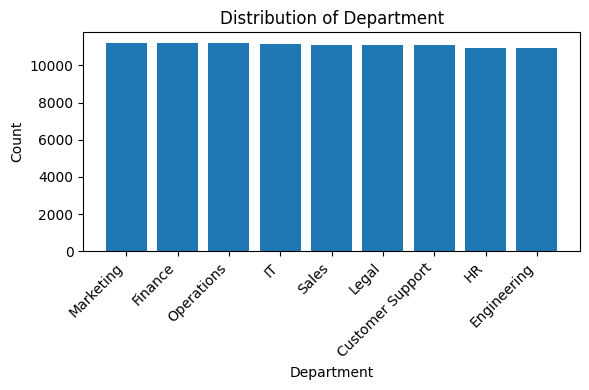

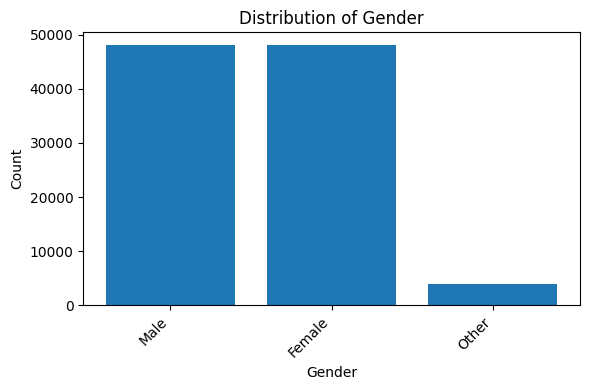

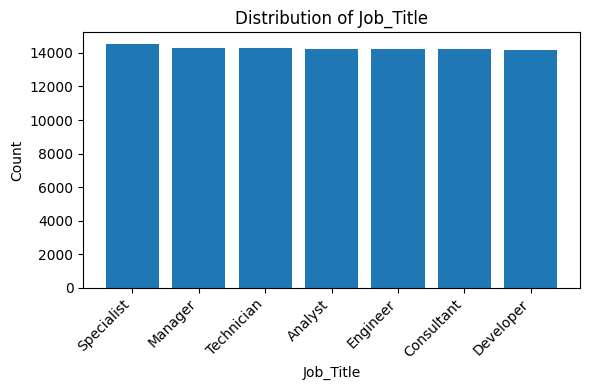

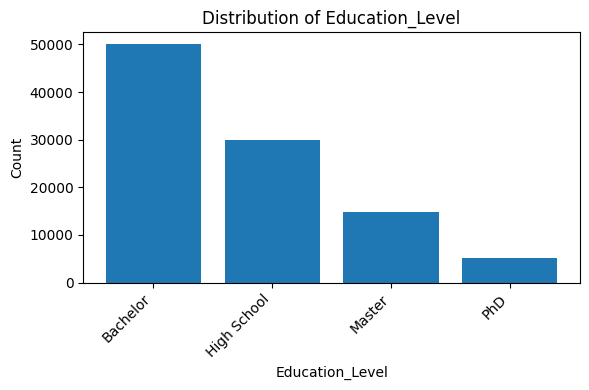

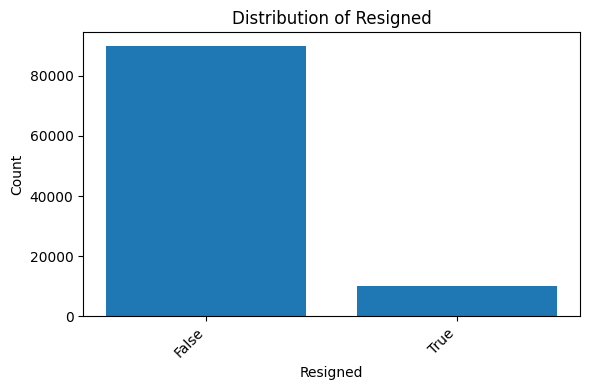

In [ ]:
import matplotlib.pyplot as plt


categorical_cols = ["Department", "Gender", "Job_Title", "Education_Level", "Resigned"]

for c in categorical_cols:
    plt.figure(figsize=(6,4))
    vc = df[c].value_counts().sort_values(ascending=False)
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"bar_{c}.png", dpi=200)
    plt.show()


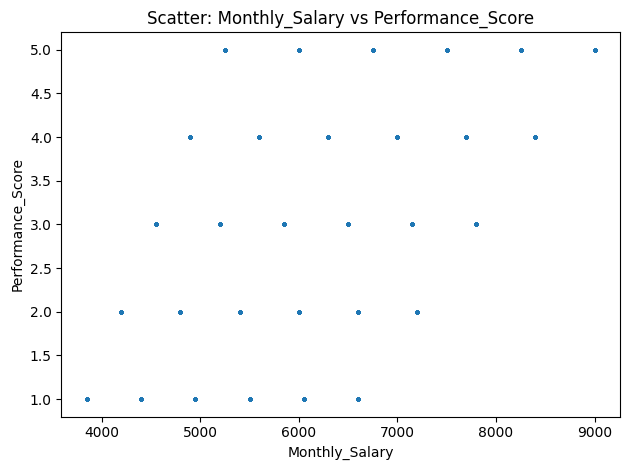

Saved -> hr_eda_figs\scatter_Monthly_Salary_vs_Performance_Score.png


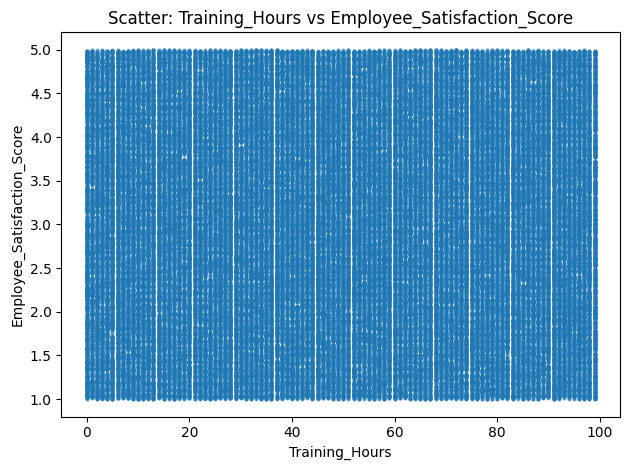

Saved -> hr_eda_figs\scatter_Training_Hours_vs_Employee_Satisfaction_Score.png


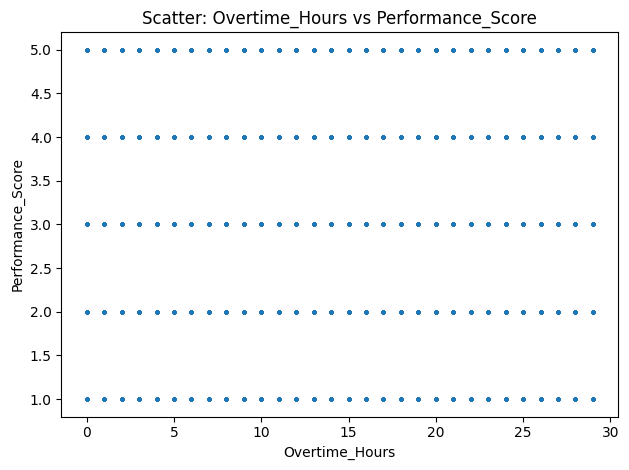

Saved -> hr_eda_figs\scatter_Overtime_Hours_vs_Performance_Score.png


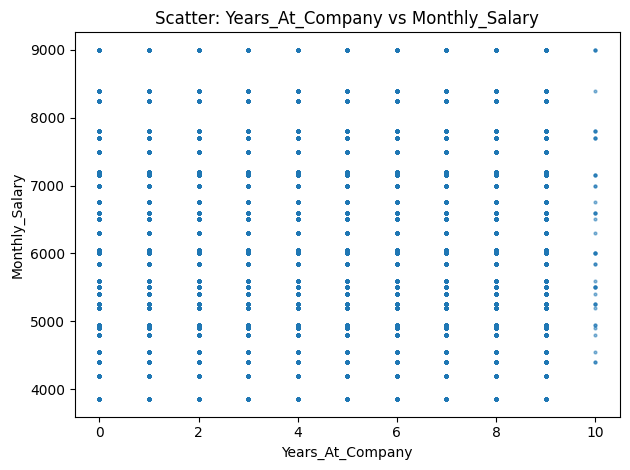

Saved -> hr_eda_figs\scatter_Years_At_Company_vs_Monthly_Salary.png


In [ ]:

pairs = [
    ("Monthly_Salary", "Performance_Score"),
    ("Training_Hours", "Employee_Satisfaction_Score"),
    ("Overtime_Hours", "Performance_Score"),
    ("Years_At_Company", "Monthly_Salary")
]
for x, y in pairs:
    if x in df.columns and y in df.columns:
        plt.figure()
        plt.scatter(df[x], df[y], s=4, alpha=0.5)
        plt.xlabel(x); plt.ylabel(y); plt.title(f"Scatter: {x} vs {y}")
        savefig_show(f"scatter_{x}_vs_{y}.png")


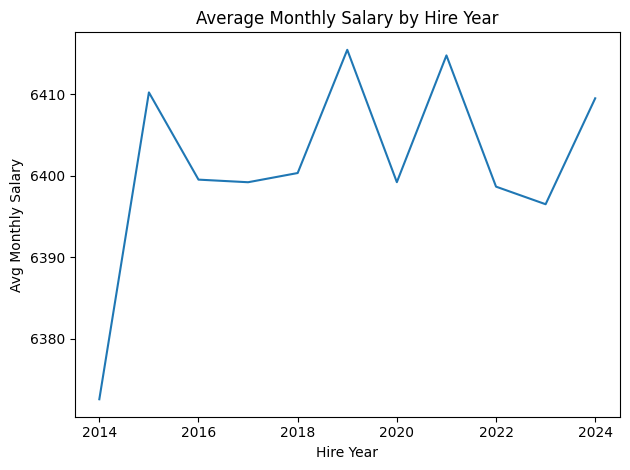

Saved -> hr_eda_figs\line_avg_salary_by_year.png


In [ ]:

if "Hire_Date" in df.columns and pd.api.types.is_datetime64_any_dtype(df["Hire_Date"]):
    tmp = df.dropna(subset=["Hire_Date"]).copy()
    tmp["Hire_Year"] = tmp["Hire_Date"].dt.year
  
    s = tmp.groupby("Hire_Year")["Monthly_Salary"].mean().sort_index()
    if not s.empty:
        plt.figure()
        plt.plot(s.index, s.values)
        plt.xlabel("Hire Year"); plt.ylabel("Avg Monthly Salary")
        plt.title("Average Monthly Salary by Hire Year")
        savefig_show("line_avg_salary_by_year.png")


In [ ]:

bullets = []

def safe_corr(a, b):
    if a in df.columns and b in df.columns:
        x = df[[a,b]].dropna()
        if len(x) > 1:
            return x.corr().iloc[0,1]
    return np.nan

pairs = [
    ("Monthly_Salary","Performance_Score"),
    ("Training_Hours","Employee_Satisfaction_Score"),
    ("Overtime_Hours","Performance_Score"),
    ("Years_At_Company","Monthly_Salary")
]
for x, y in pairs:
    r = safe_corr(x, y)
    if not np.isnan(r):
        bullets.append(f"Correlation({x}, {y}) = {r:.3f}")

if "Remote_Work_Frequency" in df.columns and "Employee_Satisfaction_Score" in df.columns:
    t = df.groupby("Remote_Work_Frequency")["Employee_Satisfaction_Score"].mean().dropna()
    if not t.empty:
        top = t.idxmax()
        bullets.append(f"Highest mean satisfaction at Remote_Work_Frequency = {top}%.")

if "Promotions" in df.columns and "Performance_Score" in df.columns:
    perf_by_prom = df.groupby("Promotions")["Performance_Score"].mean()
    if not perf_by_prom.empty and perf_by_prom.is_monotonic_increasing:
        bullets.append("Average performance increases monotonically with promotions.")
    else:
        bullets.append("Average performance generally increases with promotions (not strictly monotonic).")

print("=== DISCUSSION HIGHLIGHTS ===")
for b in bullets:
    print("-", b)


=== DISCUSSION HIGHLIGHTS ===
- Correlation(Monthly_Salary, Performance_Score) = 0.510
- Correlation(Training_Hours, Employee_Satisfaction_Score) = -0.001
- Correlation(Overtime_Hours, Performance_Score) = -0.001
- Correlation(Years_At_Company, Monthly_Salary) = -0.001
- Highest mean satisfaction at Remote_Work_Frequency = 25%.
- Average performance generally increases with promotions (not strictly monotonic).


In [ ]:

print("Numeric describe:")
display(df[numeric_cols].describe().T)

print("Ordinal describe:")
ord_exist = [c for c in ordinal_cols if c in df.columns and df[c].dtype != 'category']
if ord_exist:
    display(df[ord_exist].describe().T)

print("Categorical top-5:")
for c in categorical_cols[:5]:
    print(f"\n{c}")
    print(df[c].value_counts().head(10))


Numeric describe:


,count,mean,std,min,25%,50%,75%,max
Age,100000.0,41.02941,11.244121,22.0,31.0,41.0,51.0,60.0
Years_At_Company,100000.0,4.47607,2.869336,0.0,2.0,4.0,7.0,10.0
Monthly_Salary,100000.0,6403.21100,1372.508717,3850.0,5250.0,6500.0,7500.0,9000.0
Work_Hours_Per_Week,100000.0,44.95695,8.942003,30.0,37.0,45.0,53.0,60.0
Projects_Handled,100000.0,24.43117,14.469584,0.0,12.0,24.0,37.0,49.0
Overtime_Hours,100000.0,14.51493,8.664026,0.0,7.0,15.0,22.0,29.0
Sick_Days,100000.0,7.00855,4.331591,0.0,3.0,7.0,11.0,14.0
Team_Size,100000.0,10.01356,5.495405,1.0,5.0,10.0,15.0,19.0
Training_Hours,100000.0,49.50606,28.890383,0.0,25.0,49.0,75.0,99.0
Promotions,100000.0,0.99972,0.815872,0.0,0.0,1.0,2.0,2.0


Ordinal describe:


,count,mean,std,min,25%,50%,75%,max
Performance_Score,100000.0,2.995430,1.414726,1.0,2.00,3.0,4.00,5.0
Employee_Satisfaction_Score,100000.0,2.999088,1.150719,1.0,2.01,3.0,3.99,5.0
Remote_Work_Frequency,100000.0,50.090500,35.351157,0.0,25.00,50.0,75.00,100.0


Categorical top-5:

Department
Department
Marketing           11216
Finance             11200
Operations          11181
IT                  11131
Sales               11122
Legal               11118
Customer Support    11116
HR                  10960
Engineering         10956
Name: count, dtype: int64

Gender
Gender
Male      48031
Female    48001
Other      3968
Name: count, dtype: int64

Job_Title
Job_Title
Specialist    14507
Manager       14325
Technician    14285
Analyst       14261
Engineer      14217
Consultant    14210
Developer     14195
Name: count, dtype: int64


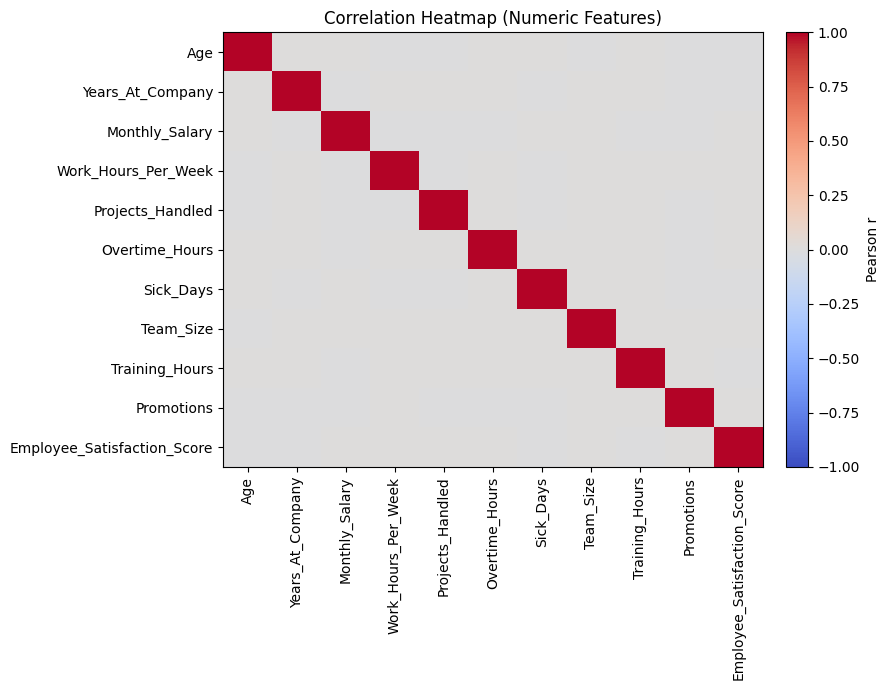

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ["Employee_ID"]]

corr = df[num_cols].corr(method="pearson")


plt.figure(figsize=(9, 7))
im = plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Pearson r")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()



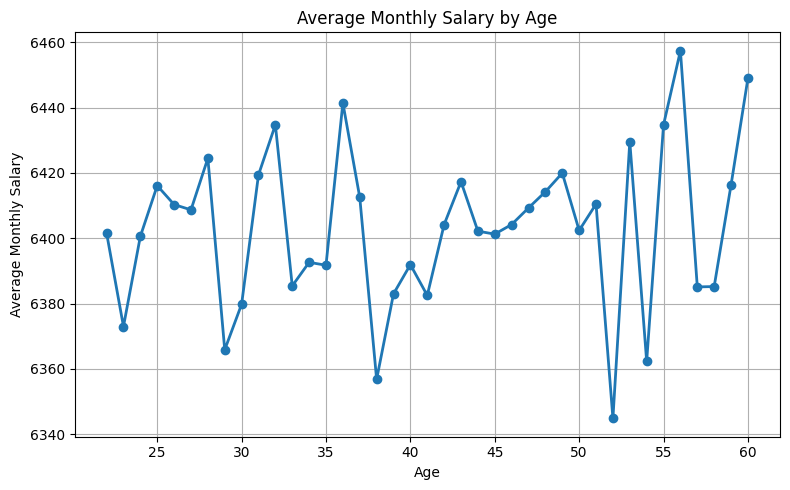

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


age_salary = df.groupby("Age")["Monthly_Salary"].mean().reset_index()


plt.figure(figsize=(8,5))
plt.plot(age_salary["Age"], age_salary["Monthly_Salary"], marker='o', linewidth=2)
plt.title("Average Monthly Salary by Age")
plt.xlabel("Age")
plt.ylabel("Average Monthly Salary")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\eren_\AppData\Local\Temp\ipykernel_23752\3582023507.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_salary_by_perf = df.groupby("Performance_Score")["Monthly_Salary"].mean()


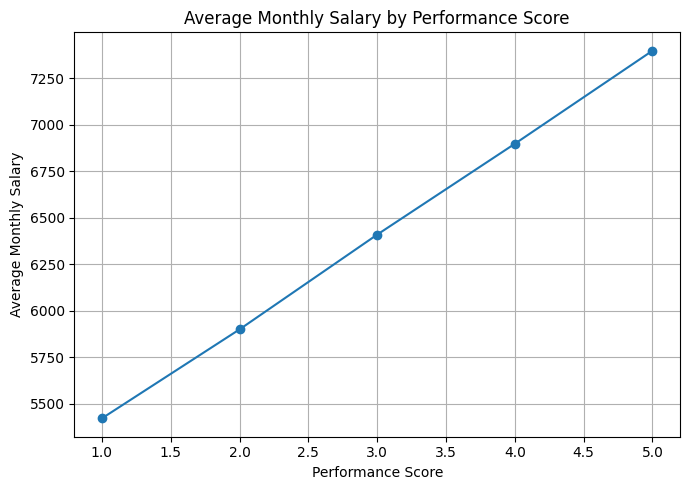

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


avg_salary_by_perf = df.groupby("Performance_Score")["Monthly_Salary"].mean()


plt.figure(figsize=(7,5))
plt.plot(avg_salary_by_perf.index, avg_salary_by_perf.values, marker='o', linestyle='-')
plt.title("Average Monthly Salary by Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Average Monthly Salary")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\eren_\AppData\Local\Temp\ipykernel_23752\167983826.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_projects_by_perf = df.groupby("Performance_Score")["Projects_Handled"].mean()


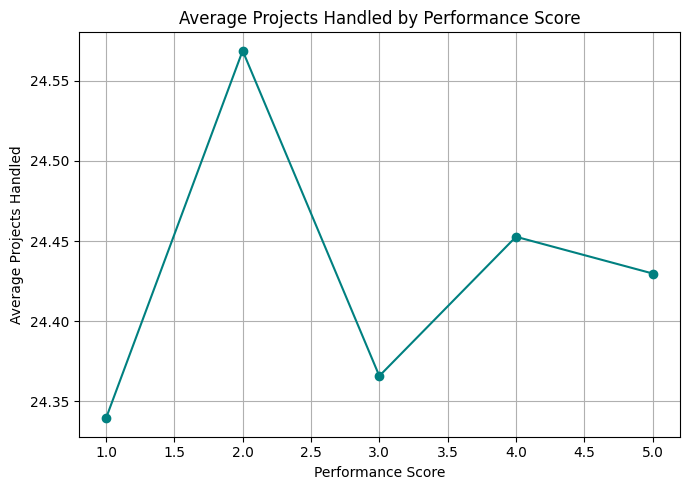

In [ ]:

avg_projects_by_perf = df.groupby("Performance_Score")["Projects_Handled"].mean()

plt.figure(figsize=(7,5))
plt.plot(avg_projects_by_perf.index, avg_projects_by_perf.values, marker='o', linestyle='-', color='teal')
plt.title("Average Projects Handled by Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Average Projects Handled")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\eren_\AppData\Local\Temp\ipykernel_23752\141087553.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_overtime_by_perf = df.groupby("Performance_Score")["Overtime_Hours"].mean()


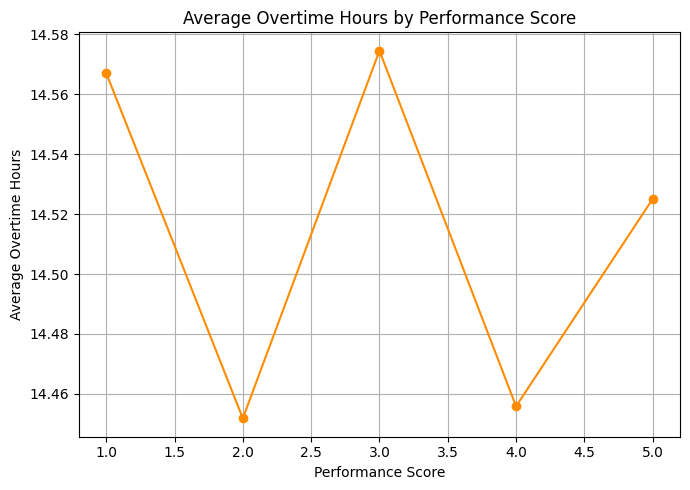

In [ ]:

avg_overtime_by_perf = df.groupby("Performance_Score")["Overtime_Hours"].mean()

plt.figure(figsize=(7,5))
plt.plot(avg_overtime_by_perf.index, avg_overtime_by_perf.values, marker='o', linestyle='-', color='darkorange')
plt.title("Average Overtime Hours by Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Average Overtime Hours")
plt.grid(True)
plt.tight_layout()
plt.show()


   Age   Age_Group  Monthly_Salary Salary_Level
0   55      Senior          6750.0       Medium
1   29       Young          7500.0       Medium
2   55      Senior          5850.0       Medium
3   48      Senior          4800.0          Low
4   36  Mid-career          4800.0          Low


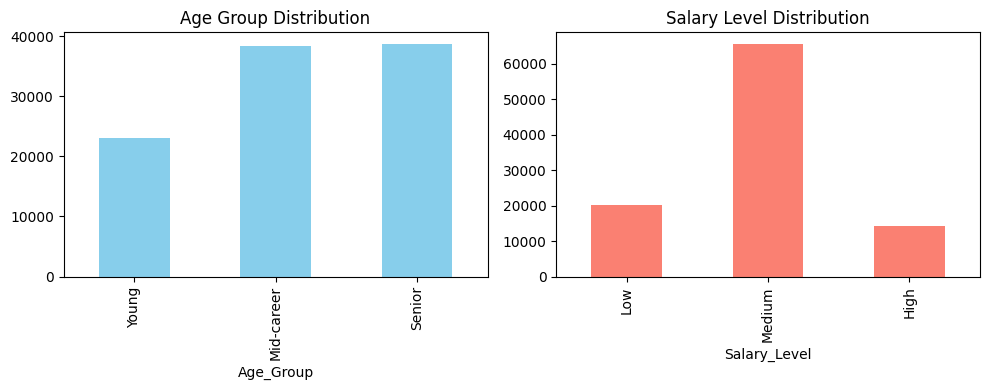

In [ ]:
import pandas as pd


age_bins = [0, 30, 45, 65]
age_labels = ["Young", "Mid-career", "Senior"]
df["Age_Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, include_lowest=True)


salary_bins = [0, 5000, 8000, df["Monthly_Salary"].max()]
salary_labels = ["Low", "Medium", "High"]
df["Salary_Level"] = pd.cut(df["Monthly_Salary"], bins=salary_bins, labels=salary_labels, include_lowest=True)


print(df[["Age", "Age_Group", "Monthly_Salary", "Salary_Level"]].head())

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,4))
df["Age_Group"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="skyblue", title="Age Group Distribution")
df["Salary_Level"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="salmon", title="Salary Level Distribution")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

standard_cols = ["Monthly_Salary", "Training_Hours", "Overtime_Hours"]
scaler = StandardScaler()
df[standard_cols] = scaler.fit_transform(df[standard_cols])

minmax_cols = ["Employee_Satisfaction_Score", "Remote_Work_Frequency"]
minmax = MinMaxScaler()
df[minmax_cols] = minmax.fit_transform(df[minmax_cols])

df[standard_cols + minmax_cols].describe().round(2)


,Monthly_Salary,Training_Hours,Overtime_Hours,Employee_Satisfaction_Score,Remote_Work_Frequency
count,100000.00,100000.00,100000.00,100000.00,100000.00
mean,-0.00,0.00,0.00,0.50,0.50
std,1.00,1.00,1.00,0.29,0.35
min,-1.86,-1.71,-1.68,0.00,0.00
25%,-0.84,-0.85,-0.87,0.25,0.25
50%,0.07,-0.02,0.06,0.50,0.50
75%,0.80,0.88,0.86,0.75,0.75
max,1.89,1.71,1.67,1.00,1.00


In [ ]:
import pandas as pd


cat_cols = ["Department", "Gender", "Education_Level"]


df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print(df_encoded.filter(like="Department").head())
print(df_encoded.filter(like="Gender").head())
print(df_encoded.filter(like="Education").head())


   Department_Customer Support  Department_Engineering  Department_Finance  \
0                        False                   False               False   
1                        False                   False                True   
2                        False                   False                True   
3                         True                   False               False   
4                        False                    True               False   

   Department_HR  Department_IT  Department_Legal  Department_Marketing  \
0          False           True             False                 False   
1          False          False             False                 False   
2          False          False             False                 False   
3          False          False             False                 False   
4          False          False             False                 False   

   Department_Operations  Department_Sales  
0                  False           

Explained variance ratio by PC: [0.1162 0.078  0.0779]
Cumulative (PC1+PC2): 0.1942
Cumulative (PC1+PC2+PC3): 0.2721


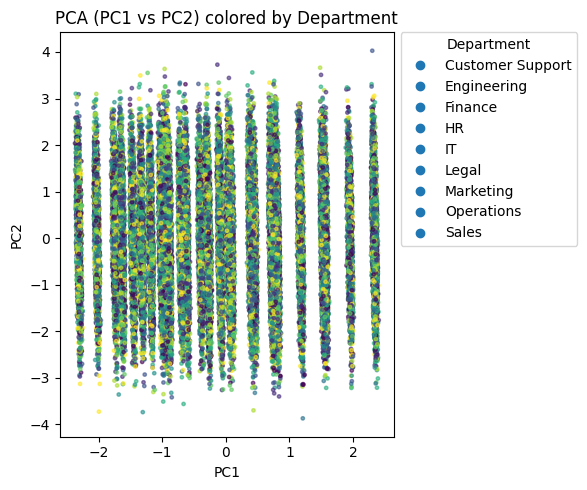

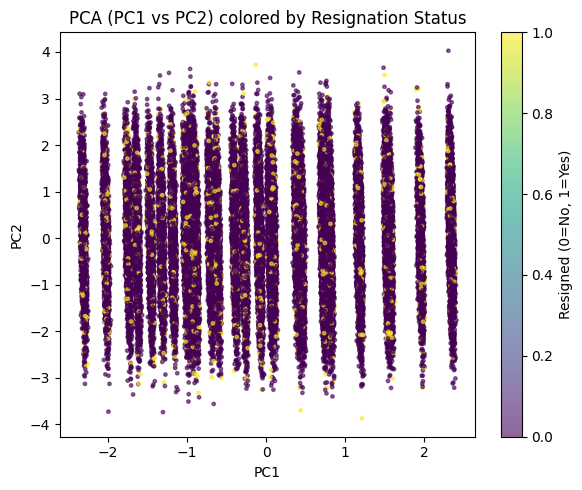

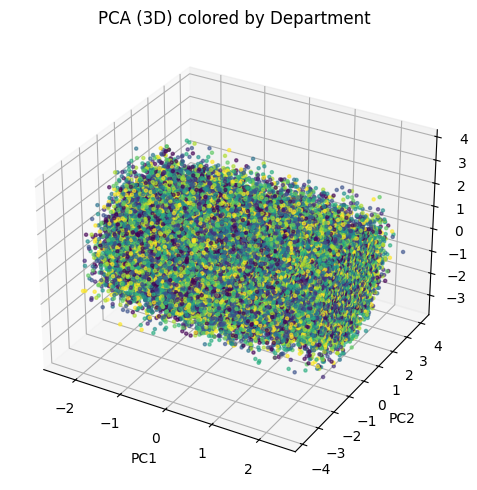

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in ["Employee_ID"]]

X = df[num_cols].copy()

scaler = StandardScaler()
X_std = scaler.fit_transform(X)


pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_std)

expl = pca.explained_variance_ratio_
print("Explained variance ratio by PC:", np.round(expl, 4))
print("Cumulative (PC1+PC2):", np.round(expl[:2].sum(), 4))
print("Cumulative (PC1+PC2+PC3):", np.round(expl[:3].sum(), 4))


dept = df["Department"].astype("category")
dept_codes = dept.cat.codes.values
dept_labels = list(dept.cat.categories)

plt.figure(figsize=(6,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=dept_codes, s=6, alpha=0.6)

handles = []
for i, lab in enumerate(dept_labels):
    handles.append(plt.Line2D([], [], marker='o', linestyle='', label=lab))
plt.legend(handles=handles, title="Department", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (PC1 vs PC2) colored by Department")
plt.tight_layout()
plt.savefig("pca_2d_department.png", dpi=200)
plt.show()


if "Resigned" in df.columns:
    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Resigned"].astype(int).values, s=6, alpha=0.6)
    cbar = plt.colorbar()
    cbar.set_label("Resigned (0=No, 1=Yes)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA (PC1 vs PC2) colored by Resignation Status")
    plt.tight_layout()
    plt.savefig("pca_2d_resigned.png", dpi=200)
    plt.show()


from mpl_toolkits.mplot3d import Axes3D  
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=dept_codes, s=5, alpha=0.6)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA (3D) colored by Department")
plt.tight_layout()
plt.savefig("pca_3d.png", dpi=200)
plt.show()


In [ ]:
import pandas as pd


cols = ["Monthly_Salary", "Overtime_Hours", "Training_Hours"]

iqr_summary = pd.DataFrame(columns=["Attribute", "Q1", "Q3", "IQR", "Lower", "Upper", "Outliers", "Outliers_%"])


for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_pct = (outliers / len(df)) * 100
    
    iqr_summary.loc[len(iqr_summary)] = [col, round(Q1,2), round(Q3,2), round(IQR,2), 
                                         round(lower_bound,2), round(upper_bound,2),
                                         outliers, round(outlier_pct,2)]


print(iqr_summary)



        Attribute    Q1    Q3   IQR  Lower  Upper  Outliers  Outliers_%
0  Monthly_Salary -0.84  0.80  1.64  -3.30   3.26         0         0.0
1  Overtime_Hours -0.87  0.86  1.73  -3.46   3.46         0         0.0
2  Training_Hours -0.85  0.88  1.73  -3.44   3.48         0         0.0


In [ ]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd


target_col = "Resigned"  

X = df.drop(columns=[target_col])
y = df[target_col]

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)


df_augmented = pd.concat([X_res, y_res], axis=1)

print("Class counts before:")
print(y.value_counts())
print("\nClass counts after augmentation:")
print(y_res.value_counts())


Class counts before:
Resigned
False    89990
True     10010
Name: count, dtype: int64

Class counts after augmentation:
Resigned
False    89990
True     89990
Name: count, dtype: int64
